# Jereme Carne — Dynon Flight Data Regression

- Author: [Jereme Carne](https://github.com/j-carne/)
- Repository: [datafun-07-regression](https://github.com/j-carne/datafun-07-regression/)
- Purpose: Apply linear regression to Dynon avionics flight data — does RPM predict average EGT?
- Date: 2026-06

## Dataset Information

- Dataset: Dynon EFB avionics recording from a general aviation flight
- 14,131 samples at 0.5-second intervals
- Feature (x): RPM (left engine)
- Target (y): Average EGT across 4 cylinders
- Source: Personal aircraft flight data (kept local, not pushed to GitHub)

## Section 1. Project Setup and Imports

In [1]:
import logging
import os
from typing import Final

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

LOG: logging.Logger = get_logger("P07", level="DEBUG")
log_header(LOG, "P07")

DATASET_NAME: Final[str] = "dynon_data"
FEATURE_COL: Final[str] = "rpm_l"
TARGET_COL: Final[str] = "avg_egt"
FEATURE_LABEL: Final[str] = "RPM (left engine)"
TARGET_LABEL: Final[str] = "Average EGT (deg C)"

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

LOG.info("Imports complete.")

2026-06-22 21:01:07 | INFO | P07 | === RUN START ===
2026-06-22 21:01:07 | INFO | P07 | project=P07
2026-06-22 21:01:07 | INFO | P07 | repo_dir=datafun-07-regression
2026-06-22 21:01:07 | INFO | P07 | python=3.14.5
2026-06-22 21:01:07 | INFO | P07 | os=Windows 11
2026-06-22 21:01:07 | INFO | P07 | shell=powershell
2026-06-22 21:01:07 | INFO | P07 | cwd=notebooks
2026-06-22 21:01:07 | INFO | P07 | github_actions=False
2026-06-22 21:01:07 | INFO | P07 | Imports complete.


## Section 2. Load the Data

In [2]:
# Move up one level so paths match the project root
os.chdir("..")
print(os.getcwd())

c:\Repos\datafun-07-regression


In [3]:
LOG.info(f"Loading dataset: {DATASET_NAME}")

df_raw: pd.DataFrame = pd.read_csv(f"data/raw/{DATASET_NAME}.csv", low_memory=False)

df = pd.DataFrame()
df["rpm_l"] = pd.to_numeric(df_raw["RPM L"], errors="coerce")
df["egt_1"] = pd.to_numeric(df_raw["EGT 1 (deg C)"], errors="coerce")
df["egt_2"] = pd.to_numeric(df_raw["EGT 2 (deg C)"], errors="coerce")
df["egt_3"] = pd.to_numeric(df_raw["EGT 3 (deg C)"], errors="coerce")
df["egt_4"] = pd.to_numeric(df_raw["EGT 4 (deg C)"], errors="coerce")

df["avg_egt"] = df[["egt_1", "egt_2", "egt_3", "egt_4"]].mean(axis=1)

LOG.info(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

2026-06-22 21:01:07 | INFO | P07 | Loading dataset: dynon_data
2026-06-22 21:01:07 | INFO | P07 | Loaded: 14131 rows, 6 columns


## Section 3. Prepare a Modeling View

In [4]:
LOG.info("Creating modeling view (dropping rows missing feature or target)")

df_model: pd.DataFrame = df[[FEATURE_COL, TARGET_COL]].dropna().copy()

count_original: int = df.shape[0]
count_model: int = df_model.shape[0]
count_dropped: int = count_original - count_model

LOG.info(f"Original rows: {count_original}")
LOG.info(f"Model rows:    {count_model}")
LOG.info(f"Rows dropped:  {count_dropped}")

2026-06-22 21:01:07 | INFO | P07 | Creating modeling view (dropping rows missing feature or target)
2026-06-22 21:01:07 | INFO | P07 | Original rows: 14131
2026-06-22 21:01:07 | INFO | P07 | Model rows:    14122
2026-06-22 21:01:07 | INFO | P07 | Rows dropped:  9


## Section 4. Build the Feature Matrix X and Target Vector y

In [5]:
LOG.info("Building feature matrix X and target vector y")

X: np.ndarray = df_model[[FEATURE_COL]].values
y: np.ndarray = df_model[TARGET_COL].values

LOG.debug(f"X shape: {X.shape}  (rows, features)")
LOG.debug(f"y shape: {y.shape}  (rows,)")

2026-06-22 21:01:07 | INFO | P07 | Building feature matrix X and target vector y
2026-06-22 21:01:07 | DEBUG | P07 | X shape: (14122, 1)  (rows, features)
2026-06-22 21:01:07 | DEBUG | P07 | y shape: (14122,)  (rows,)


## Section 5. Fit a Straight Line

In [6]:
LOG.info("Fitting a linear regression (scikit-learn)")

model = LinearRegression()
model.fit(X, y)

slope: float = model.coef_[0]
intercept: float = model.intercept_

LOG.info(f"Slope:     {slope:.6f}")
LOG.info(f"Intercept: {intercept:.6f}")
LOG.info(f"Fitted line: {TARGET_COL} = {slope:.5f} * {FEATURE_COL} + {intercept:.3f}")

2026-06-22 21:01:07 | INFO | P07 | Fitting a linear regression (scikit-learn)
2026-06-22 21:01:07 | INFO | P07 | Slope:     0.151141
2026-06-22 21:01:07 | INFO | P07 | Intercept: 332.787118
2026-06-22 21:01:07 | INFO | P07 | Fitted line: avg_egt = 0.15114 * rpm_l + 332.787


## Section 6. Predict

In [7]:
LOG.info("Computing fitted values for every observed row")
y_hat: np.ndarray = model.predict(X)

# Example prediction at cruise RPM
X_example = np.array([[2400]])
y_example = model.predict(X_example)
LOG.info(f"Example prediction: rpm=2400 -> avg_egt={y_example[0]:.1f} deg C")

2026-06-22 21:01:07 | INFO | P07 | Computing fitted values for every observed row
2026-06-22 21:01:07 | INFO | P07 | Example prediction: rpm=2400 -> avg_egt=695.5 deg C


## Section 7. Examine the Fit (Residuals, R-squared, RMSE)

In [8]:
LOG.info("Computing residuals (actual - fitted)")
residuals: np.ndarray = y - y_hat

r2: float = r2_score(y, y_hat)
rmse: float = np.sqrt(mean_squared_error(y, y_hat))

LOG.info(f"R-squared: {r2:.4f}")
LOG.info(f"RMSE:      {rmse:.4f}")

2026-06-22 21:01:07 | INFO | P07 | Computing residuals (actual - fitted)
2026-06-22 21:01:07 | INFO | P07 | R-squared: 0.6850
2026-06-22 21:01:07 | INFO | P07 | RMSE:      74.0172


## Section 8. Make Plots

2026-06-22 21:01:07 | INFO | P07 | ---- Creating Scatter Plot with Fitted Line ----------
2026-06-22 21:01:07 | INFO | P07 | ----   Set x to RPM (left engine) -----------------------
2026-06-22 21:01:07 | INFO | P07 | ----   Set y to Average EGT (deg C) -------------------------


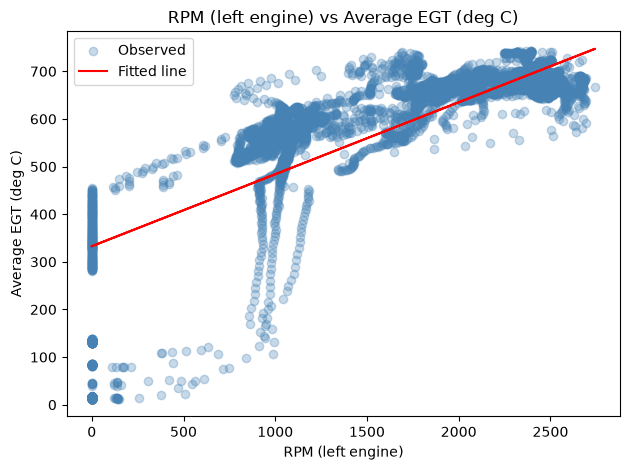

In [9]:
LOG.info("---- Creating Scatter Plot with Fitted Line ----------")
LOG.info(f"----   Set x to {FEATURE_LABEL} -----------------------")
LOG.info(f"----   Set y to {TARGET_LABEL} -------------------------")

feature_values: np.ndarray = df_model[FEATURE_COL].values

plt.figure()
plt.scatter(feature_values, y, alpha=0.3, label="Observed", color="steelblue")
plt.plot(feature_values, y_hat, color="red", label="Fitted line")
plt.xlabel(FEATURE_LABEL)
plt.ylabel(TARGET_LABEL)
plt.title(f"{FEATURE_LABEL} vs {TARGET_LABEL}")
plt.legend()
plt.tight_layout()
plt.savefig("docs/images/dynon_regression_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

2026-06-22 21:01:08 | INFO | P07 | ------ Creating Residual Plot --------------------------
2026-06-22 21:01:08 | INFO | P07 | ------   Set x to RPM (left engine) ----------------------
2026-06-22 21:01:08 | INFO | P07 | ------   Set y to the residual (actual - fitted) -------


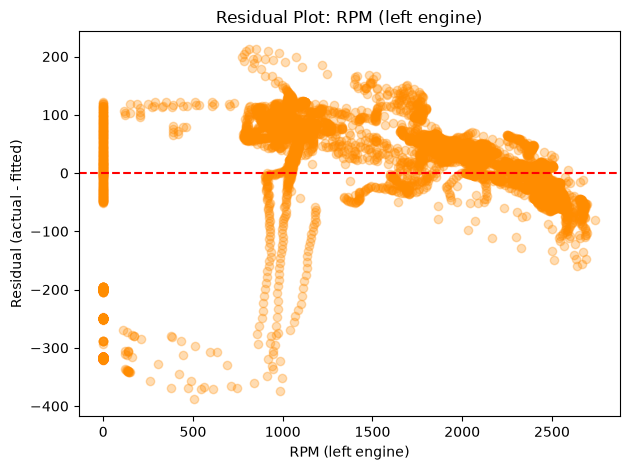

In [10]:
LOG.info("------ Creating Residual Plot --------------------------")
LOG.info(f"------   Set x to {FEATURE_LABEL} ----------------------")
LOG.info("------   Set y to the residual (actual - fitted) -------")

plt.figure()
plt.scatter(feature_values, residuals, alpha=0.3, color="darkorange")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel(FEATURE_LABEL)
plt.ylabel("Residual (actual - fitted)")
plt.title(f"Residual Plot: {FEATURE_LABEL}")
plt.tight_layout()
plt.savefig("docs/images/dynon_regression_residual.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 9. Summary and Next Steps

In [11]:
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset: {DATASET_NAME}")
LOG.info(f"Feature (x): {FEATURE_COL}")
LOG.info(f"Target  (y): {TARGET_COL}")
LOG.info(f"Original rows: {count_original}")
LOG.info(f"Model rows:    {count_model}")
LOG.info("Fitted line:")
LOG.info(f"  {TARGET_COL} = {slope:.5f} * {FEATURE_COL} + {intercept:.3f}")
LOG.info(f"R-squared: {r2:.4f}")
LOG.info(f"RMSE:      {rmse:.4f}")
LOG.info("======================")
LOG.info("Review the fit numbers (R-squared, RMSE).")
LOG.info("Look at the fitted-line plot and the residual plot.")
LOG.info("Decide if a straight line is a fair description.")
LOG.info("If the residuals show a pattern, a straight line is not -")
LOG.info("and that is a real finding worth reporting.")
LOG.info("======================")
LOG.info("EDA workflow complete")
LOG.info("========================")
LOG.info("Executed successfully!")
LOG.info("========================")

2026-06-22 21:01:08 | INFO | P07 | ========================
2026-06-22 21:01:08 | INFO | P07 | SUMMARY
2026-06-22 21:01:08 | INFO | P07 | ========================
2026-06-22 21:01:08 | INFO | P07 | Dataset: dynon_data
2026-06-22 21:01:08 | INFO | P07 | Feature (x): rpm_l
2026-06-22 21:01:08 | INFO | P07 | Target  (y): avg_egt
2026-06-22 21:01:08 | INFO | P07 | Original rows: 14131
2026-06-22 21:01:08 | INFO | P07 | Model rows:    14122
2026-06-22 21:01:08 | INFO | P07 | Fitted line:
2026-06-22 21:01:08 | INFO | P07 |   avg_egt = 0.15114 * rpm_l + 332.787
2026-06-22 21:01:08 | INFO | P07 | R-squared: 0.6850
2026-06-22 21:01:08 | INFO | P07 | RMSE:      74.0172
2026-06-22 21:01:08 | INFO | P07 | ======================
2026-06-22 21:01:08 | INFO | P07 | Review the fit numbers (R-squared, RMSE).
2026-06-22 21:01:08 | INFO | P07 | Look at the fitted-line plot and the residual plot.
2026-06-22 21:01:08 | INFO | P07 | Decide if a straight line is a fair description.
2026-06-22 21:01:08 | INFO